## Group P - Dataset Version 35
**This notebook focuses on predicting price using features from the topic21_v35_train.csv dataset.**

*The model will be evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²), with R² being the primary metric of interest.*


## Supervised Regression Task

This is a supervised learning problem because each training example includes both input features and the corresponding output — the actual price.

Since the target variable (price) is continuous and numeric rather than categorical, the task is a regression problem rather than a classification problem.


## Installing all the Software/Libraries.


In [83]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor, RandomForestRegressor, RandomForestClassifier,HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.pipeline import make_pipeline
from scipy.stats import randint, uniform
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import zscore, pearsonr
import math

!pip install category_encoders
from category_encoders import TargetEncoder

plt.rcParams['figure.figsize'] = [20, 15]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12


In [84]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/topic21_v35_train.csv', sep=',')

display(df.head())
display(df.info())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,0,1,2,3,4,brand,model,trim,body_type,fuel_type,transmission_type,engine_capacity_cc,horsepower,exterior_color,interior_color,warranty,city,seller_type,price
0,-19.752963,0.304111,-0.445249,NaN,-7.819551,Porsche,Carrera / 911,Turbo S,Coupe,Petrol,Automatic Transmission,NaN,600 - 699 HP,Grey,Unknown,Yes,Dubai,Dealer,699000
1,0.484306,0.892970,-0.471971,1.073699,13.691026,Honda,Odyssey,Touring,Van,Petrol,Automatic Transmission,2500 - 2999 cc,200 - 299 HP,White,Beige,No,Dubai,Owner,49000
2,-8.607706,0.590507,NaN,NaN,6.937271,Jeep,Wrangler Unlimited,Sahara Plus,SUV,Petrol,Automatic Transmission,3000 - 3499 cc,200 - 299 HP,Silver,Black,No,Dubai,Owner,150000
3,-6.737678,2.097223,-0.532921,2.171827,7.771556,Audi,A4,Standard,Sedan,Petrol,Automatic Transmission,2000 - 2499 cc,200 - 299 HP,White,Black,Does not apply,Sharjah,Dealer,28000
4,-19.454629,2.235233,-0.670155,2.544760,3.798203,Audi,TT,Standard,Coupe,Petrol,Automatic Transmission,2000 - 2499 cc,200 - 299 HP,Black,Unknown,Does not apply,Dubai,Owner,18999


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7962 entries, 0 to 7961
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   0                   7407 non-null   float64
 1   1                   7171 non-null   float64
 2   2                   7277 non-null   float64
 3   3                   7314 non-null   float64
 4   4                   7337 non-null   float64
 5   brand               7962 non-null   object 
 6   model               7962 non-null   object 
 7   trim                7951 non-null   object 
 8   body_type           7962 non-null   object 
 9   fuel_type           7962 non-null   object 
 10  transmission_type   7962 non-null   object 
 11  engine_capacity_cc  6362 non-null   object 
 12  horsepower          7584 non-null   object 
 13  exterior_color      7962 non-null   object 
 14  interior_color      7962 non-null   object 
 15  warranty            7962 non-null   object 
 16  city  

None

## Exploratory data analysis


In [85]:
df.describe()

,0,1,2,3,4,price
count,7407.000000,7.171000e+03,7277.000000,7314.000000,7337.000000,7962.000000
mean,-6.801891,1.947424e+06,-0.462824,2.546305,7.069478,163331.653228
std,6.815820,1.164390e+08,0.123912,43.444412,6.162831,188397.899880
min,-29.816325,1.137867e-01,-0.834789,0.238174,-11.841854,1000.000000
25%,-8.874057,2.826793e-01,-0.552500,0.503461,5.633530,44999.250000
50%,-5.807237,4.481655e-01,-0.477912,0.736576,7.894615,93000.000000
75%,-2.245745,8.126410e-01,-0.390182,1.184240,10.240636,207000.000000
max,4.728823,7.487469e+09,-0.065343,2442.331803,25.769459,999900.000000


### Analyzing Price Distribution for Expensive Brands

We focus on analyzing the price distribution for specific high-end brands. In particular, we examine the quartiles of the price variable to understand the spread and range of values. Additionally, we compute the mean and standard deviation to gain further insight into the central tendency and variability of prices within these brands.

In [86]:
brands_to_analyze = ['Porsche', 'Mercedes-Benz', 'BMW', 'Audi']
summary_table = pd.DataFrame()

for brand in brands_to_analyze:
    brand_df = df[df['brand'] == brand]
    stats = brand_df['price'].describe()
    stats.name = brand
    summary_table = pd.concat([summary_table, stats], axis=1)

summary_table = summary_table.T
display(summary_table)


,count,mean,std,min,25%,50%,75%,max
Porsche,335.0,294046.892537,259189.217907,1049.0,88200.0,219000.0,449000.0,999000.0
Mercedes-Benz,1231.0,236324.241267,213022.929931,1000.0,83000.0,175000.0,315000.0,999900.0
BMW,691.0,181495.869754,144650.814200,15000.0,74995.0,132000.0,255000.0,740000.0
Audi,290.0,139161.727586,123073.604101,17000.0,49900.0,91900.0,192925.0,670000.0


**Check for Duplicates**


In [87]:
df.duplicated().sum()

np.int64(0)

**Summary of Missing and Placeholder Values**

This section provides a concise overview of missing and placeholder values across all columns in the dataset. By counting occurrences of NaN, 'Other', and 'Unknown', it helps identify potential data quality issues that may require cleaning or preprocessing before further analysis or modeling.

In [88]:
summary = {
    'Column': [],
    'NaN Count': [],
    'Other Count': [],
    'Unknown Count': []
}

for column in df.columns:
    summary['Column'].append(column)
    summary['NaN Count'].append(df[column].isna().sum())
    summary['Other Count'].append((df[column] == 'Other').sum())
    summary['Unknown Count'].append((df[column] == 'Unknown').sum())

summary_df = pd.DataFrame(summary)
display(summary_df)

,Column,NaN Count,Other Count,Unknown Count
0,0,555,0,0
1,1,791,0,0
2,2,685,0,0
3,3,648,0,0
4,4,625,0,0
5,brand,0,0,0
6,model,0,30,0
7,trim,11,1586,0
8,body_type,0,52,0
9,fuel_type,0,0,0


In [89]:
df['interior_color'] = df['interior_color'].replace("Unknown", np.nan)

**Exploring Feature Correlations**

A correlation heatmap is an effective tool for this type of exploratory data analysis, as it visually highlights patterns and dependencies that may inform feature selection or model design.

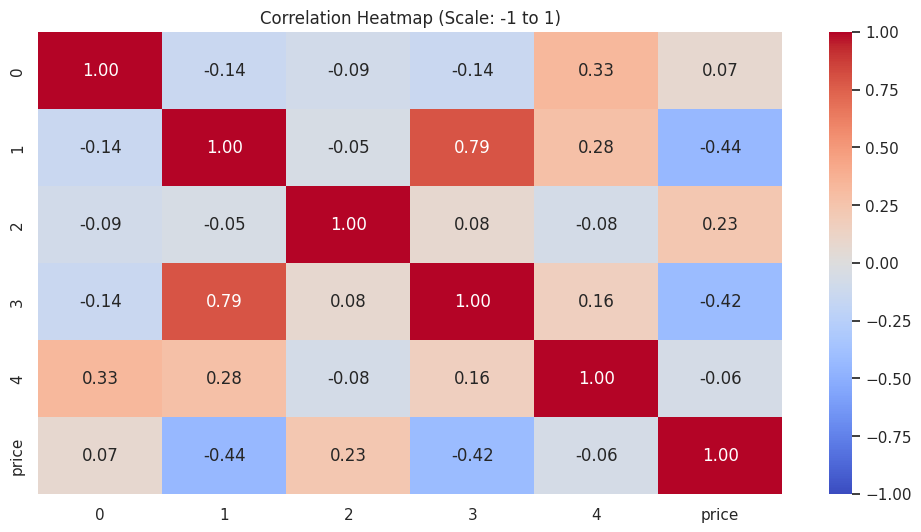

In [90]:
numerical_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 6))
sns.heatmap(
    numerical_df.corr(method='spearman'),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,
    vmax=1
)
plt.title("Correlation Heatmap (Scale: -1 to 1)")
plt.show()

**Box Plot**
* Shows that car prices are heavily right-skewed — most cars are affordable, but a few are extremely expensive.

* Makes it easy to spot unusually low and high-priced cars that could distort model performance.

* The log scale compresses extreme values, allowing better visualization of the central distribution.




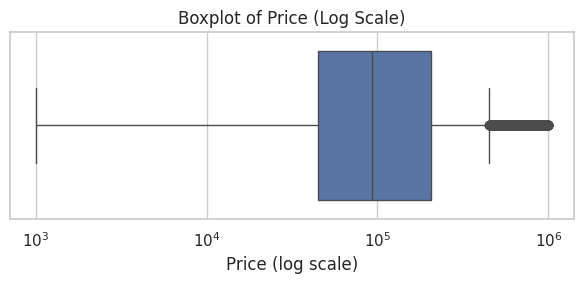

In [91]:

plt.figure(figsize=(6, 3))
sns.boxplot(x=df["price"])
plt.xscale("log")
plt.title("Boxplot of Price (Log Scale)")
plt.xlabel("Price (log scale)")
plt.tight_layout()
plt.show()


# Data preprocessing



**Log Transformation**
* To reduce skewness and normalize the distribution of numerical features, we applied a logarithmic transformation:

    * 1_log: Created by applying the natural logarithm to feature 1.

    * 3_log: Created by applying the natural logarithm to the absolute values of feature 3, to handle potential negative values.

This helps stabilize variance and can improve the performance of machine learning models that assume normally distributed input features.

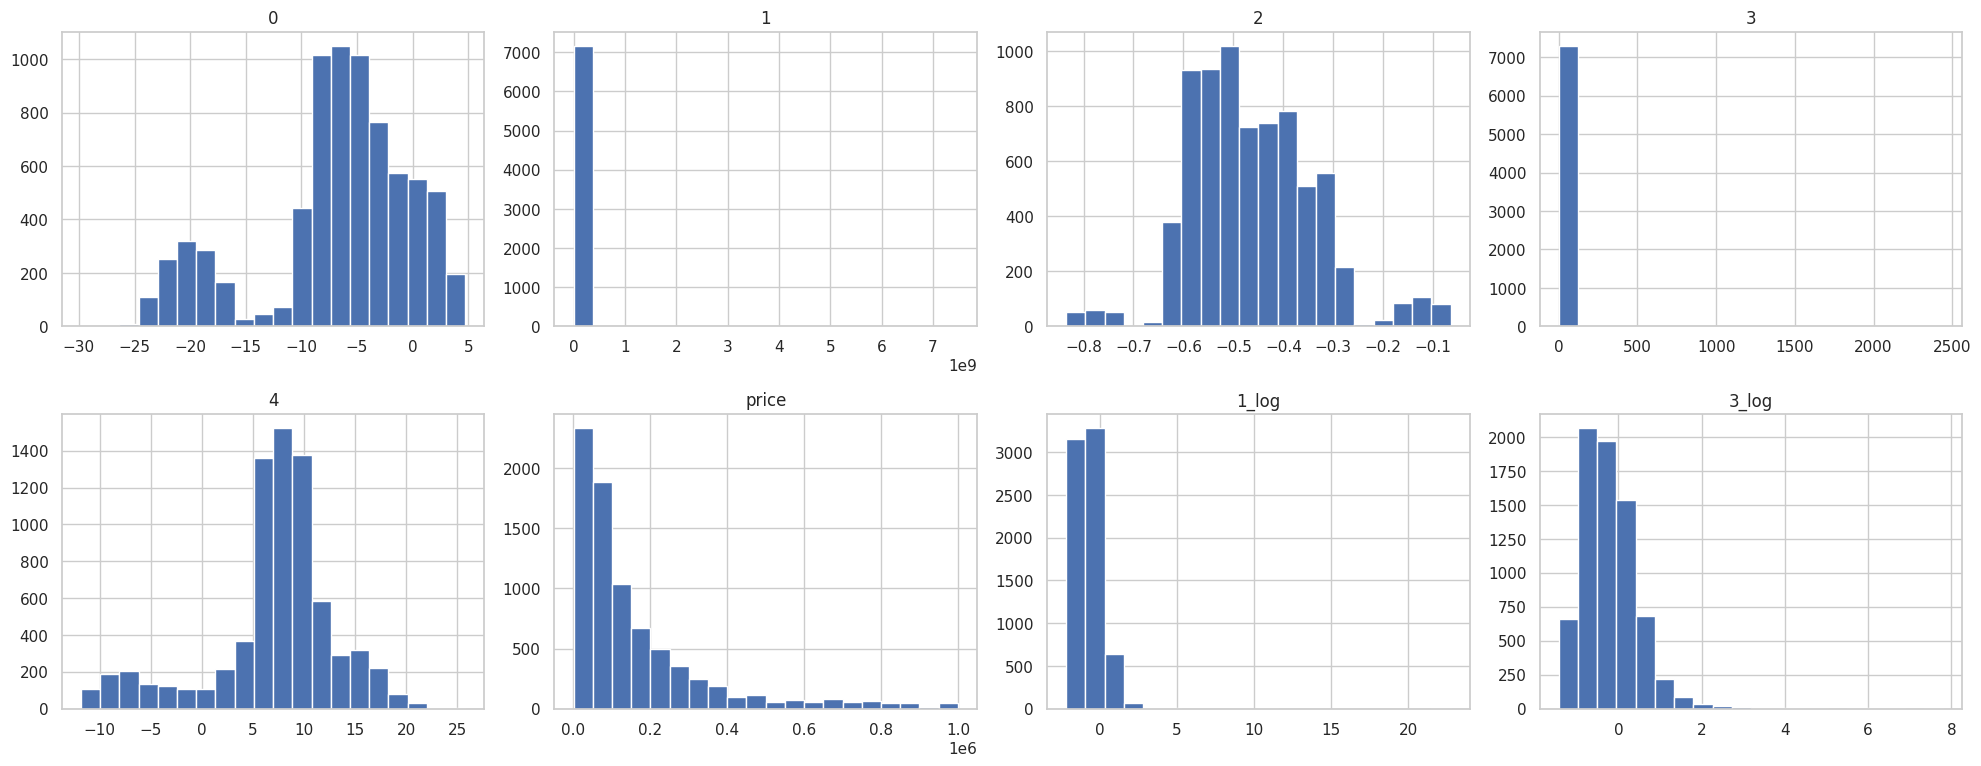

In [92]:
df['1_log'] = np.log(df['1'])
df['3_log'] = np.log(np.abs(df['3']))

df.hist(bins=20, layout=(4, 4))
plt.tight_layout()
plt.show()

**Numerical Columns to 'Price' comparison.**

* We use Scatter plots to explore how each numerical feature relates to the target variable (price).

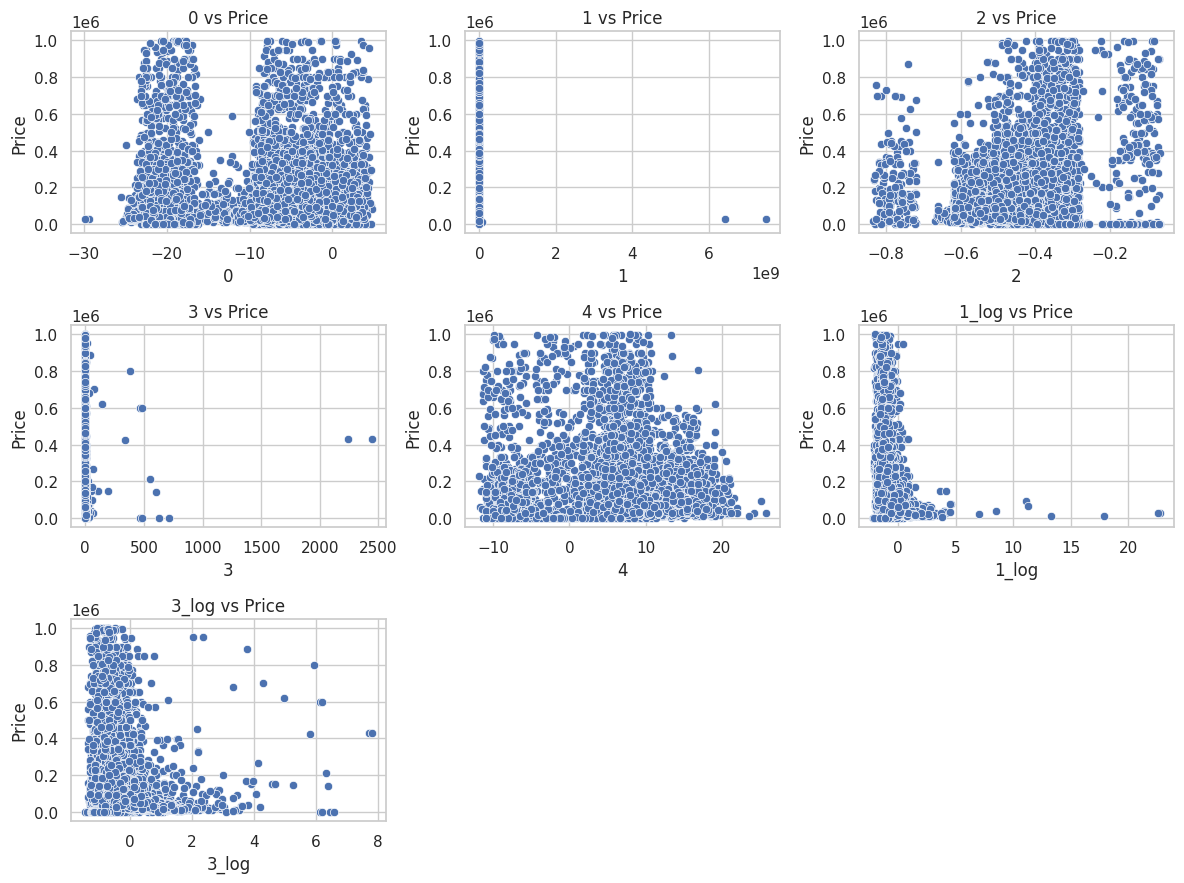

In [93]:
numerical_features = df.select_dtypes(include=['number']).columns.drop('price')

sns.set(style="whitegrid", context="notebook")

n = len(numerical_features)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3), squeeze=False)

for i, col in enumerate(numerical_features):
    r, c = divmod(i, cols)
    sns.scatterplot(data=df, x=col, y='price', ax=axes[r][c])
    axes[r][c].set_title(f'{col} vs Price')
    axes[r][c].set_xlabel(col)
    axes[r][c].set_ylabel('Price')

for j in range(i + 1, rows * cols):
    r, c = divmod(j, cols)
    fig.delaxes(axes[r][c])

plt.tight_layout()
plt.show()


## Transformer Class: RangeToNumeric
Fields 'engine capacity' and 'horsepower' are stored as ranges or categorical strings.

These string formats can't be directly used for numeric analysis or modeling, so we convert them into singe numeric values.


In [94]:
class RangeToNumeric(BaseEstimator, TransformerMixin):
    """
    A scikit-learn compatible transformer that converts string ranges in
    engine capacity and horsepower columns to numeric values.

    - '1000 - 1500 cc' → 1250.0
    - '1500+ cc' → 1500.0
    - 'Missing' / 'Unknown' → np.nan
    """

    def __init__(self, engine_col='engine_capacity_cc', hp_col='horsepower'):
        self.engine_col = engine_col
        self.hp_col = hp_col

    def fit(self, X, y=None):
        return self  # Nothing to learn from the data

    def transform(self, X):
        X = X.copy()

        def convert_engine_capacity(val):
            if isinstance(val, str):
                if ' - ' in val:
                    try:
                        low, high = val.replace(' cc', '').split(' - ')
                        return (int(low) + int(high)) / 2
                    except:
                        return np.nan
                elif '+' in val:
                    try:
                        return float(val.replace('+ cc', ''))
                    except:
                        return np.nan
                elif val in ['Missing', 'Unknown']:
                    return np.nan
            return val if isinstance(val, float) else np.nan

        def convert_horsepower(val):
            if isinstance(val, str):
                if ' - ' in val:
                    try:
                        low, high = val.replace(' HP', '').split(' - ')
                        return (int(low) + int(high)) / 2
                    except:
                        return np.nan
                elif '+' in val:
                    try:
                        return float(val.replace('+ HP', ''))
                    except:
                        np.nan
                elif val in ['Missing', 'Unknown']:
                    return np.nan
            return val if isinstance(val, float) else np.nan

        if self.engine_col in X.columns:
            X[self.engine_col] = X[self.engine_col].apply(convert_engine_capacity)
        else:
            print(f"{self.engine_col} not found in DataFrame.")

        if self.hp_col in X.columns:
            X[self.hp_col] = X[self.hp_col].apply(convert_horsepower)
        else:
            print(f"{self.hp_col} not found in DataFrame.")

        return X

## Transformer Class: WarrantyTransformer

Warranty information appears as categorical labels like: 'Yes', 'No', 'Does Not Apply'
We transform into a binary numerical format for modeling:
*   'Yes' becomes 1
*   'No' and 'Does Not Apply' become 0

## Transformer Class: RareBrandGrouper

In [95]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class RareBrandGrouper(BaseEstimator, TransformerMixin):

    def __init__(self, column='brand', threshold=5):
        self.column = column
        self.threshold = threshold
        self.rare_brands_ = None

    def fit(self, X, y=None):
        # Calculate brand counts and identify rare brands
        brand_counts = X[self.column].value_counts()
        self.rare_brands_ = brand_counts[brand_counts < self.threshold].index.tolist()
        return self

    def transform(self, X):
        X = X.copy()
        # Replace rare brands with 'Other'
        X[self.column] = X[self.column].apply(lambda x: 'Other' if x in self.rare_brands_ else x)
        return X

In [103]:
class WarrantyTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, input_col='warranty', output_col='warranty_numerical'):
        self.input_col = input_col
        self.output_col = output_col

    def fit(self, X, y=None):
        # No fitting needed for this stateless transformer
        return self

    def transform(self, X):
        X = X.copy()

        if self.input_col in X.columns:
            # Treat 'Does not apply' as 'No'
            X[self.input_col] = X[self.input_col].replace('Does not apply', 'No')

            # Convert 'Yes' to 1, others to 0
            X[self.output_col] = X[self.input_col].apply(lambda x: 1 if x == 'Yes' else 0)

            # Drop the original categorical column
            X.drop(columns=[self.input_col], inplace=True)
        else:
            print(f"{self.input_col} not found in DataFrame.")

        return X

# Identifying best parameters for Models.
## HistGradientBoostingClassifier, also TheBestModel

In [107]:
# Step 1: Separate features and target
X = df.drop('price', axis=1)
y = df['price']

# Step 2: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Step 3: Detect feature types
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

# Step 4: Separate brand from other categorical features
categorical_features_no_brand = [c for c in categorical_features if c != 'brand']

# Step 5: Define numeric pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Step 6: Define pipeline for other categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('targetenc', TargetEncoder())
])

# Step 7: Define pipeline for brand column (rare brand grouping + encoding)
brand_pipeline = Pipeline(steps=[
    ('rare_brand', RareBrandGrouper(column='brand', threshold=5)),
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('targetenc', TargetEncoder())
])
ranges_to_num_pipeline = Pipeline(steps=[
    ('range_to_num', RangeToNumeric()),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
warranty_pipeline = Pipeline(steps=[
    ('range_to_num', WarrantyTransformer()),
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Step 8: Define preprocessor with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('brand', brand_pipeline, ['brand']),
    ('to_number', ranges_to_num_pipeline, ['engine_capacity_cc', 'horsepower']),
    ('to_warranty', warranty_pipeline, ['warranty']),
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features_no_brand)
])

# Step 9: Build full pipeline with model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', HistGradientBoostingRegressor(early_stopping=True, max_iter=1000, random_state=42))
])

HistGradientBoosting_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', HistGradientBoostingRegressor(early_stopping=True, max_iter=1000))
])

# Step 2: Define parameter grid for min_samples_split
# param_grid = {
#     'model__learning_rate': [0.01, 0.05, 0.1],
#     'model__max_iter': [100, 500, 1000],
#     'model__max_depth': [1, 2, 5, 10, None],
#     'model__min_samples_leaf': [5, 10, 20],
#     'model__max_leaf_nodes': [15, 31, 63]
# }

param_grid = {
    'model__learning_rate': [0.01, 0.005],
    'model__min_samples_leaf': [1,2,3, 5, 10],
    'model__max_leaf_nodes': [50, 100, 150]
}

# Step 4: Grid search
grid_search = GridSearchCV(
  HistGradientBoosting_pipeline,
  param_grid,
  cv=5,
  scoring='r2',
  n_jobs=-1,
  verbose=2
  )

grid_search.fit(X_train, y_train)

# Step 5: Evaluate best model
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

MSE_train = mean_squared_error(best_model.predict(X_train), y_train)
MSE_test = mean_squared_error(y_pred, y_test)

print("Best model__learning_rate:", grid_search.best_params_['model__learning_rate'],
      "Best model__min_samples_leaf:", grid_search.best_params_['model__min_samples_leaf'],
      "Best model__max_leaf_nodes:", grid_search.best_params_['model__max_leaf_nodes'])


print("MSE train:", MSE_train)
print("RMSE train:", np.sqrt(MSE_train))
print("R^2 train:", best_model.score(X_train, y_train))

print("MSE test:", MSE_test)
print("RMSE test:", np.sqrt(MSE_test))
print("R^2 test:", best_model.score(X_test, y_test))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters:
{'model__learning_rate': 0.01, 'model__max_leaf_nodes': 50, 'model__min_samples_leaf': 3}

Training metrics:
MSE train: 2787300371.1674
RMSE train: 52794.8896
R^2 train: 0.9201

Test metrics:
MSE test: 12503407399.7616
RMSE test: 111818.6362
R^2 test: 0.6762


Fitting 5 folds for each of 48 candidates, totalling 240 fits
* Best model__learning_rate: 0.01
* Best model__max_depth: None
* Best model__min_samples_leaf: 3 Best
* model__max_leaf_nodes: 100


* MSE train: 1929448994.8974233
* RMSE train: 43925.49367847131
* R^2 train: 0.9447069683054822
* MSE test: 12104738380.17461
* RMSE test: 110021.53598352738
* R^2 test: 0.6865593212455943

/tmp/ipython-input-108-2496457461.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


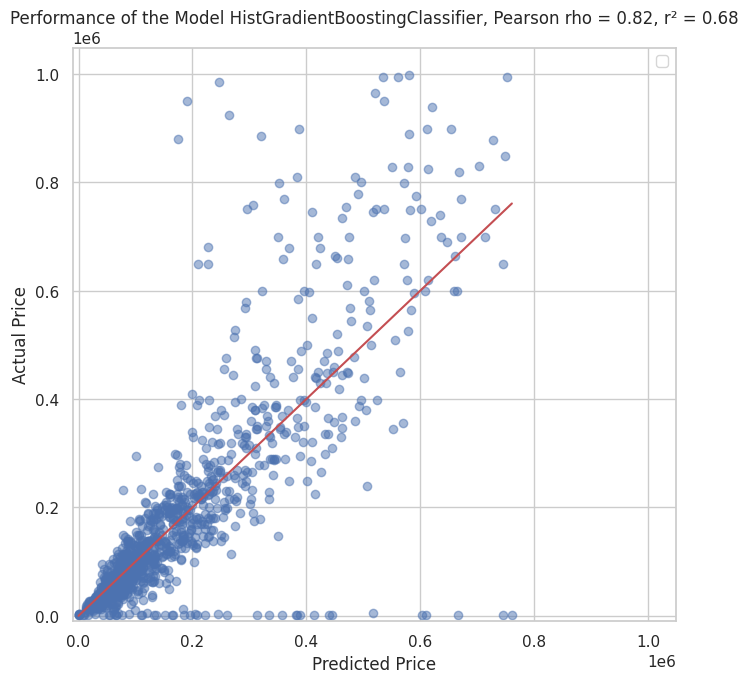

In [108]:
y_pred_clipped = np.clip(y_pred, 0, None)
plt.figure(figsize=(7, 7))  # Adjust width and height as needed

plt.scatter(y_pred_clipped, y_test, alpha=0.5)
plt.plot([0, np.min([np.max(y_pred_clipped), np.max(y_test)])], [0, np.min([np.max(y_pred_clipped), np.max(y_test)])], color='r')

plt.legend()
plt.xlabel('Predicted Price')
plt.ylabel('Actual Price')
plt.title(f"Performance of the Model HistGradientBoostingClassifier, Pearson rho = {round(pearsonr(y_pred_clipped, y_test)[0], 2)}, r² = {round(r2_score(y_test, y_pred_clipped), 2)}")

upper_lim = np.max([np.max(y_pred_clipped), np.max(y_test)])+50000
lower_lim = np.min([np.min(y_pred_clipped), np.min(y_test)])-10000
plt.xlim(lower_lim, upper_lim)
plt.ylim(lower_lim, upper_lim)
plt.tight_layout()
plt.show()

This code performs hyperparameter tuning on three ensemble regression models—ExtraTrees, HistGradientBoosting, and RandomForest—using GridSearchCV with 5-fold cross-validation. It preprocesses numerical features with median imputation and categorical features with frequent-value imputation followed by target encoding.

**The best tuned model for each algorithm is saved for further evaluation.**

In [ ]:
#  : Separate features and target
X = df.drop('price', axis=1)
y = df['price']

#  : Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

#  : Detect feature types
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

#  : Separate brand from other categorical features
categorical_features_no_brand = [c for c in categorical_features if c != 'brand']

#  : Pipelines for different data types and transformations
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('targetenc', TargetEncoder())
])

brand_pipeline = Pipeline(steps=[
    ('rare_brand', RareBrandGrouper(column='brand', threshold=5)),
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('targetenc', TargetEncoder())
])

ranges_to_num_pipeline = Pipeline(steps=[
    ('range_to_num', RangeToNumeric()),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

warranty_pipeline = Pipeline(steps=[
    ('warranty', WarrantyTransformer()),
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

#  : Combine preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('brand', brand_pipeline, ['brand']),
    ('to_number', ranges_to_num_pipeline, ['engine_capacity_cc', 'horsepower']),
    ('to_warranty', warranty_pipeline, ['warranty']),
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features_no_brand)
])

#  : Define model configurations dict
model_configs = {
    'ExtraTreesRegressor': {
        'model': ExtraTreesRegressor(random_state=42),
        'param_grid': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [50, None],
            'model__min_samples_split': [3, 5],
            'model__min_samples_leaf': [1, 2],
            'model__max_features': [10, 20]
        }
    },

    'HistGradientBoostingRegressor': {
        'model': HistGradientBoostingRegressor(early_stopping=True, max_iter=1000, random_state=42),
        'param_grid': {
            'model__learning_rate': [0.01],
            'model__min_samples_leaf': [2, 3],
            'model__max_leaf_nodes': [50, 100]
        }
    },

    'RandomForestRegressor': {
        'model': RandomForestRegressor(random_state=42),
        'param_grid': {
            'model__n_estimators': [500],
            'model__min_samples_split': [2, 5],
            'model__min_samples_leaf': [1, 4],
            'model__max_features': ['sqrt', 'log2']
        }
    }
}

best_models = {}

#  : Loop over models, train and tune
for model_name, config in model_configs.items():
    print(f"\nSearching best parameters for {model_name}...")

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', config['model'])
    ])

    grid_search = GridSearchCV(
        pipeline,
        param_grid=config['param_grid'],
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=2
    )

    grid_search.fit(X_train, y_train)
    best_models[model_name] = grid_search.best_estimator_

    print(f"Best parameters for {model_name}: {grid_search.best_params_}")

    # Evaluate train/test
    y_train_pred = best_models[model_name].predict(X_train)
    y_test_pred = best_models[model_name].predict(X_test)

    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)

    print(f"Train MSE: {mse_train:.4f}, RMSE: {np.sqrt(mse_train):.4f}, R^2: {best_models[model_name].score(X_train, y_train):.4f}")
    print(f"Test MSE: {mse_test:.4f}, RMSE: {np.sqrt(mse_test):.4f}, R^2: {best_models[model_name].score(X_test, y_test):.4f}")


Searching best parameters for ExtraTreesRegressor...
Fitting 5 folds for each of 32 candidates, totalling 160 fits


In [ ]:
#  : Initialize list to collect results
evaluation_results = []

#  : Loop through best models and evaluate
for model_name, best_model in best_models.items():
    print(f"Evaluating model: {model_name}")

    # Predict
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    # Metrics
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_train = np.sqrt(mse_train)
    rmse_test = np.sqrt(mse_test)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Collect results
    evaluation_results.append({
        'Model': model_name,
        'MSE Train': mse_train,
        'RMSE Train': rmse_train,
        'R² Train': r2_train,
        'MSE Test': mse_test,
        'RMSE Test': rmse_test,
        'R² Test': r2_test
    })

#  : Convert to DataFrame for easy viewing
results_df = pd.DataFrame(evaluation_results)

#  : Display or save
print("\n=== Evaluation Summary ===")
print(results_df.round(4))

## Weak Models.
* This code processes the data and trains three baseline regression models—Linear Regression, KNN, and Decision Tree—using pipelines.

In [ ]:
#  : Separate features and target
X = df.drop('price', axis=1)
y = df['price']

#  : Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

#  : Detect feature types
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

#  : Separate brand from other categorical features
categorical_features_no_brand = [c for c in categorical_features if c != 'brand']

#  ine numeric pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

#  : Define pipeline for other categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('targetenc', TargetEncoder())
])

#  : Define pipeline for brand column (rare brand grouping + encoding)
brand_pipeline = Pipeline(steps=[
    ('rare_brand', RareBrandGrouper(column='brand', threshold=5)),
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('targetenc', TargetEncoder())
])
ranges_to_num_pipeline = Pipeline(steps=[
    ('range_to_num', RangeToNumeric()),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
warranty_pipeline = Pipeline(steps=[
    ('range_to_num', WarrantyTransformer()),
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

#  : Define preprocessor with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('brand', brand_pipeline, ['brand']),
    ('to_number', ranges_to_num_pipeline, ['engine_capacity_cc', 'horsepower']),
    ('to_warranty', warranty_pipeline, ['warranty']),
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features_no_brand)
])


# 4. Model configurations
model_configs = {
    'LinearRegression': {
        'model': Ridge(),
        'param_grid': {
            'model__alpha': [0.1, 1.0, 3.0]
        }
    },
    'KNN': {
        'model': KNeighborsRegressor(),
        'param_grid': {
            'model__n_neighbors': [3, 5, 7, 9],
            'model__weights': ['uniform', 'distance'],
            'model__p': [1, 2]
        }
    },
    'DecisionTree': {
        'model': DecisionTreeRegressor(random_state=42),
        'param_grid': {
            'model__max_depth': [3, 5, 10, None],
            'model__min_samples_split': [2, 5, 10],
            'model__min_samples_leaf': [1, 2, 5]
        }
    }
}

# 5. Train and search
best_models = {}

for model_name, config in model_configs.items():
    print(f"\n Searching Best Parameters for {model_name}...")

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', config['model'])
    ])

    grid_search = GridSearchCV(
        pipeline,
        config['param_grid'],
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=2
    )

    grid_search.fit(X_train, y_train)

    best_models[model_name] = grid_search.best_estimator_

    print(f"\n Best parameters for {model_name}:")
    for key in config['param_grid'].keys():
        print(f"   {key}: {grid_search.best_params_[key]}")


 Searching Best Parameters for LinearRegression...
Fitting 5 folds for each of 3 candidates, totalling 15 fits

 Best parameters for LinearRegression:
   model__alpha: 3.0

 Searching Best Parameters for KNN...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

 Best parameters for KNN:
   model__n_neighbors: 9
   model__weights: distance
   model__p: 1

 Searching Best Parameters for DecisionTree...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [ ]:
#  : Initialize list to collect results
evaluation_results = []

#  : Loop through best models and evaluate
for model_name, best_model in best_models.items():
    print(f"Evaluating model: {model_name}")

    # Predict
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    # Metrics
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_train = np.sqrt(mse_train)
    rmse_test = np.sqrt(mse_test)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Collect results
    evaluation_results.append({
        'Model': model_name,
        'MSE Train': mse_train,
        'RMSE Train': rmse_train,
        'R² Train': r2_train,
        'MSE Test': mse_test,
        'RMSE Test': rmse_test,
        'R² Test': r2_test
    })

#  : Convert to DataFrame for easy viewing
results_df = pd.DataFrame(evaluation_results)

#  : Display or save
print("\n=== Evaluation Summary ===")
print(results_df.round(4))

**What’s Working:**

* Linear Regression shows consistent performance on train and test sets (R² ≈ 0.45). It is stable but limited in predictive power.

* KNN performs best on the test set (Test R² = 0.63), but severely overfits on the training data (Train R² = 1.00), making it unreliable in its current form.

* Decision Tree avoids strong overfitting but tends to underfit (Test R² = 0.52).

**Main Problems:**

* KNN is overfitting — there is a large gap between train and test scores.

* No model explains more than about 55% of the variance in car prices, suggesting that either the feature set is insufficient or the model complexity is too limited, except for overfitted KNN.

# Modeling Summary

### Models Evaluated
	* 1.	Ridge Regression (a regularized linear model)
	* 2.	K-Nearest Neighbors Regressor (non-parametric, based on instance-based learning)
	* 3.	Decision Tree Regressor (tree-based model prone to overfitting without pruning)
	* 4.	Random Forest Regressor (ensemble of decision trees using bagging)
	* 5.	Extra Trees Regressor (more randomized version of Random Forest)
	* 6.	HistGradientBoostingRegressor (efficient gradient boosting tree model that handles missing values natively)
Based on the R² scores on the test set, the ExtraTreesRegressor appears to be the best performing model among the ones you have evaluated so far.




### Conclusions
	* Tree-based models like HistGradientBoosting and RandomForest generally performed better in capturing non-linear patterns and feature interactions.
	* Ridge regression provided a good baseline but was limited by its linear nature.
	*	KNN and Decision Trees are sensitive to hyperparameters and data distribution, but when tuned well, can still offer solid performance.